<a href="https://colab.research.google.com/github/salma-mahmoud237/Neural-Network/blob/main/Neural_Network_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 1. Import Libraries

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
# 2. Device Configuration

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [ ]:
# Data Augmentation + Preprocessing
train_transform = transforms.Compose([

    transforms.Resize((28, 28)),

    transforms.RandomHorizontalFlip(),

    transforms.RandomRotation(10),

    transforms.ToTensor(),

    transforms.Normalize((0.5,), (0.5,))
])

In [ ]:
# Validation & Test without Augmentation
test_val_transform = transforms.Compose([

    transforms.Resize((28, 28)),

    transforms.ToTensor(),

    transforms.Normalize((0.5,), (0.5,))
])

In [ ]:
# Full Training Dataset
full_train_dataset = datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=train_transform
)

# Test Dataset
test_dataset = datasets.FashionMNIST(
    root='./data',
    train=False,
    download=True,
    transform=test_val_transform
)

100%|██████████| 26.4M/26.4M [00:02<00:00, 12.8MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 204kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.77MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 8.02MB/s]


In [ ]:
# Split Train / Validation
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size]
)

# Validation without Augmentation
val_dataset.dataset.transform = test_val_transform

# DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

print("Train Size:", len(train_dataset))
print("Validation Size:", len(val_dataset))
print("Test Size:", len(test_dataset))

Train Size: 48000
Validation Size: 12000
Test Size: 10000


In [ ]:
# Test the Loader

images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([64, 1, 28, 28])
torch.Size([64])


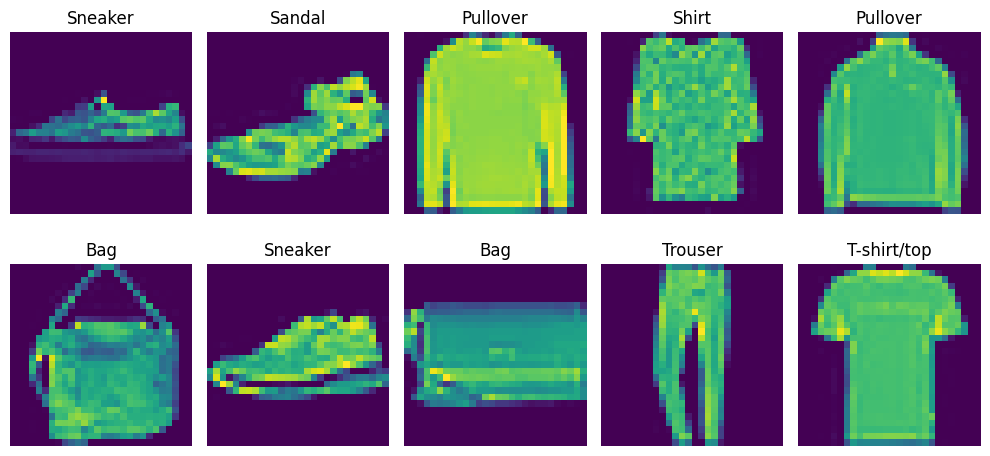

In [ ]:
classes = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress',
    'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

images, labels = next(iter(train_loader))

plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(images[i].permute(1, 2, 0))
    plt.title(classes[labels[i]])
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# 7. Build MLP Model
# Experiment 1

class MLP_Model_1(nn.Module):
    def __init__(self):
        super(MLP_Model_1, self).__init__()

        self.network = nn.Sequential(
            nn.Flatten(),

            nn.Linear(28 * 28, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(64, 10)
        )

    def forward(self, x):
        return self.network(x)

In [ ]:
# 8. Initialize Model

model1 = MLP_Model_1().to(device)
print(model1)

MLP_Model_1(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=128, bias=True)
    (2): ReLU()
    (3): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): Dropout(p=0.3, inplace=False)
    (5): Linear(in_features=128, out_features=64, bias=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=10, bias=True)
  )
)


In [ ]:
# 9. Loss Function and Optimizer

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model1.parameters(), lr=0.001)

In [ ]:
# 10. Training Function

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

best_val_loss = float('inf')

patience = 4
counter = 0

epochs = 7

for epoch in range(epochs):

    # Training Phase

    model1.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        # Reset gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model1(images)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        running_loss += loss.item()

        # Predictions
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    # Training Metrics
    train_loss = running_loss / len(train_loader)
    train_accuracy = 100 * correct / total

    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)

    # Validation Phase

    model1.eval()

    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model1(images)

            loss = criterion(outputs, labels)

            val_running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    # Validation Metrics
    val_loss = val_running_loss / len(val_loader)
    val_accuracy = 100 * val_correct / val_total

    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    # Print Results
    print(f'Epoch [{epoch+1}/{epochs}]')

    print(f'Train Loss: {train_loss:.4f} | Train Accuracy: {train_accuracy:.2f}%')

    print(f'Validation Loss: {val_loss:.4f} | Validation Accuracy: {val_accuracy:.2f}%')

    # Early Stopping

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        counter = 0

        torch.save(model1.state_dict(), 'best_model.pth')

    else:

        counter += 1

    if counter >= patience:

        print('Early stopping triggered')

        break

Epoch [1/7]
Train Loss: 0.6136 | Train Accuracy: 79.00%
Validation Loss: 0.4415 | Validation Accuracy: 83.99%
Epoch [2/7]
Train Loss: 0.4763 | Train Accuracy: 83.15%
Validation Loss: 0.4437 | Validation Accuracy: 84.57%
Epoch [3/7]
Train Loss: 0.4470 | Train Accuracy: 84.02%
Validation Loss: 0.4477 | Validation Accuracy: 84.12%
Epoch [4/7]
Train Loss: 0.4355 | Train Accuracy: 84.34%
Validation Loss: 0.4159 | Validation Accuracy: 85.77%
Epoch [5/7]
Train Loss: 0.4197 | Train Accuracy: 85.06%
Validation Loss: 0.4018 | Validation Accuracy: 86.11%
Epoch [6/7]
Train Loss: 0.4088 | Train Accuracy: 85.27%
Validation Loss: 0.3940 | Validation Accuracy: 86.19%
Epoch [7/7]
Train Loss: 0.4035 | Train Accuracy: 85.46%
Validation Loss: 0.4010 | Validation Accuracy: 85.58%


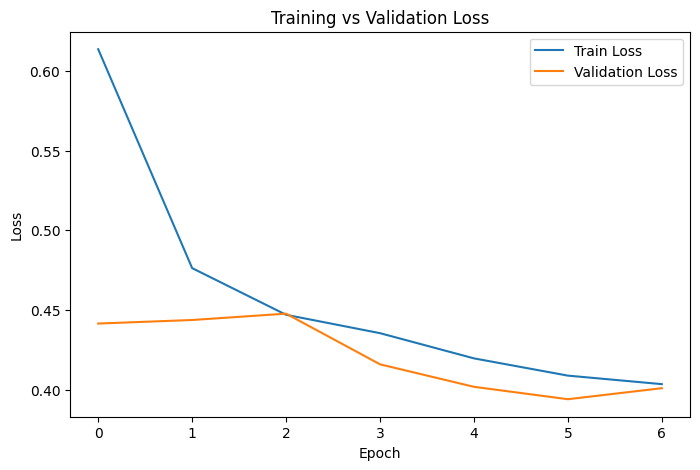

In [ ]:
# 11. Plot Loss Curves

plt.figure(figsize=(8,5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.savefig("accuracy_curve.png")
plt.show()

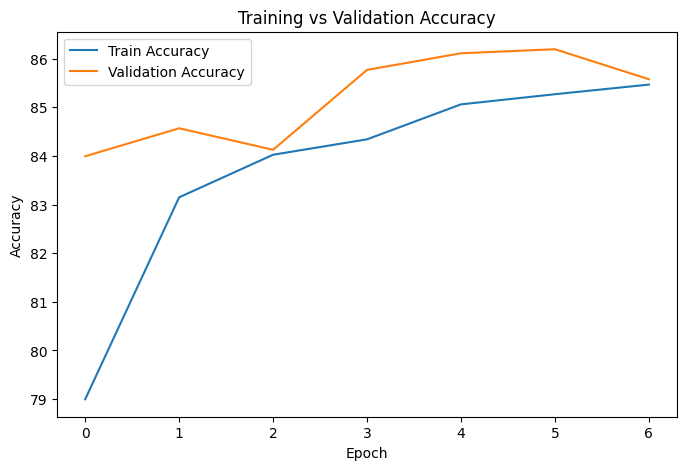

In [ ]:
# 12. Plot Accuracy Curves

plt.figure(figsize=(8,5))
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.savefig("accuracy_curve.png")
plt.show()

In [ ]:
# 13. Test Evaluation

model1.load_state_dict(torch.load('best_model.pth'))

model1.eval()

correct = 0
total = 0

y_true = []
y_pred = []

test_loss = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model1(images)

        loss = criterion(outputs, labels)
        test_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

final_accuracy = 100 * correct / total
final_loss = test_loss / len(test_loader)

print(f'Test Accuracy: {final_accuracy:.2f}%')
print(f'Test Loss: {final_loss:.4f}')

Test Accuracy: 85.58%
Test Loss: 0.4455


In [ ]:
# 14. Classification Report

print(classification_report(y_true, y_pred, target_names=classes))

              precision    recall  f1-score   support

 T-shirt/top       0.83      0.79      0.81      1000
     Trouser       0.99      0.95      0.97      1000
    Pullover       0.76      0.75      0.76      1000
       Dress       0.81      0.90      0.85      1000
        Coat       0.75      0.78      0.77      1000
      Sandal       0.94      0.92      0.93      1000
       Shirt       0.67      0.63      0.65      1000
     Sneaker       0.88      0.96      0.92      1000
         Bag       0.96      0.96      0.96      1000
  Ankle boot       0.96      0.92      0.94      1000

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000



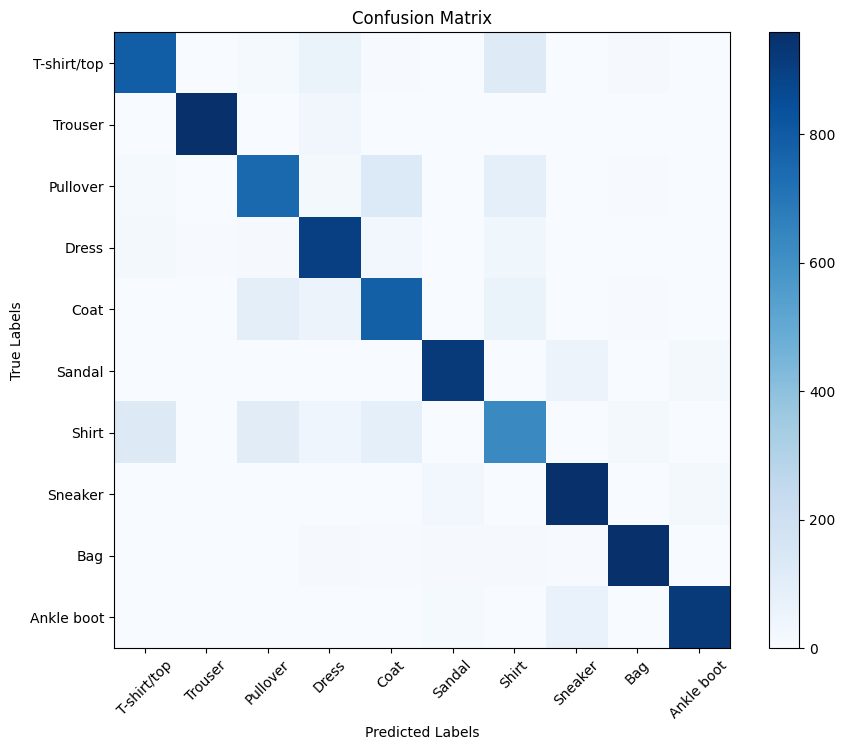

In [ ]:
# 15. Confusion Matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))
plt.imshow(cm, cmap='Blues')

plt.title('Confusion Matrix')
plt.colorbar()

plt.xticks(np.arange(10), classes, rotation=45)
plt.yticks(np.arange(10), classes)

plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.savefig("accuracy_curve.png")
plt.show()

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

# MODEL 2

class MLP_Model_2(nn.Module):

    def __init__(self):

        super(MLP_Model_2, self).__init__()

        self.network = nn.Sequential(

            nn.Flatten(),

            nn.Linear(28 * 28, 256),
            nn.Sigmoid(),
            nn.BatchNorm1d(256),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.Sigmoid(),
            nn.Dropout(0.3),

            nn.Linear(128, 10)

        )

    def forward(self, x):

        return self.network(x)

In [ ]:
# INITIALIZE MODEL

model2 = MLP_Model_2().to(device)

In [ ]:
# LOSS & OPTIMIZER

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model2.parameters(),
    lr=0.0005
)

In [ ]:
# TRAINING

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

best_val_loss = float('inf')

patience = 4
counter = 0

epochs = 10

for epoch in range(epochs):

    # TRAINING

    model2.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model2(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)

    train_accuracy = 100 * correct / total

    train_losses.append(train_loss)

    train_accuracies.append(train_accuracy)

    # VALIDATION

    model2.eval()

    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model2(images)

            loss = criterion(outputs, labels)

            val_running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)

            val_correct += (predicted == labels).sum().item()

    val_loss = val_running_loss / len(val_loader)

    val_accuracy = 100 * val_correct / val_total

    val_losses.append(val_loss)

    val_accuracies.append(val_accuracy)

    print(f'Epoch [{epoch+1}/{epochs}]')

    print(f'Train Loss: {train_loss:.4f} | Train Accuracy: {train_accuracy:.2f}%')

    print(f'Validation Loss: {val_loss:.4f} | Validation Accuracy: {val_accuracy:.2f}%')

    # EARLY STOPPING

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        counter = 0

        torch.save(model2.state_dict(), 'best_model.pth')

    else:

        counter += 1

    if counter >= patience:

        print("Early stopping triggered")

        break

Epoch [1/10]
Train Loss: 0.6708 | Train Accuracy: 79.38%
Validation Loss: 0.4523 | Validation Accuracy: 83.95%
Epoch [2/10]
Train Loss: 0.4347 | Train Accuracy: 84.76%
Validation Loss: 0.3836 | Validation Accuracy: 86.20%
Epoch [3/10]
Train Loss: 0.3938 | Train Accuracy: 86.06%
Validation Loss: 0.3879 | Validation Accuracy: 85.76%
Epoch [4/10]
Train Loss: 0.3671 | Train Accuracy: 86.79%
Validation Loss: 0.3454 | Validation Accuracy: 87.45%
Epoch [5/10]
Train Loss: 0.3480 | Train Accuracy: 87.42%
Validation Loss: 0.3384 | Validation Accuracy: 87.53%
Epoch [6/10]
Train Loss: 0.3312 | Train Accuracy: 87.96%
Validation Loss: 0.3362 | Validation Accuracy: 87.97%
Epoch [7/10]
Train Loss: 0.3177 | Train Accuracy: 88.43%
Validation Loss: 0.3239 | Validation Accuracy: 88.14%
Epoch [8/10]
Train Loss: 0.3094 | Train Accuracy: 88.71%
Validation Loss: 0.3186 | Validation Accuracy: 88.22%
Epoch [9/10]
Train Loss: 0.2965 | Train Accuracy: 89.22%
Validation Loss: 0.3103 | Validation Accuracy: 88.91%
E

In [ ]:
# TESTING

model2.load_state_dict(torch.load('best_model.pth'))

model2.eval()

correct = 0
total = 0

test_loss = 0

y_true = []
y_pred = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model2(images)

        loss = criterion(outputs, labels)

        test_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

        y_true.extend(labels.cpu().numpy())

        y_pred.extend(predicted.cpu().numpy())

final_accuracy = 100 * correct / total

final_loss = test_loss / len(test_loader)

print(f'Test Accuracy: {final_accuracy:.2f}%')

print(f'Test Loss: {final_loss:.4f}')

Test Accuracy: 88.27%
Test Loss: 0.3256


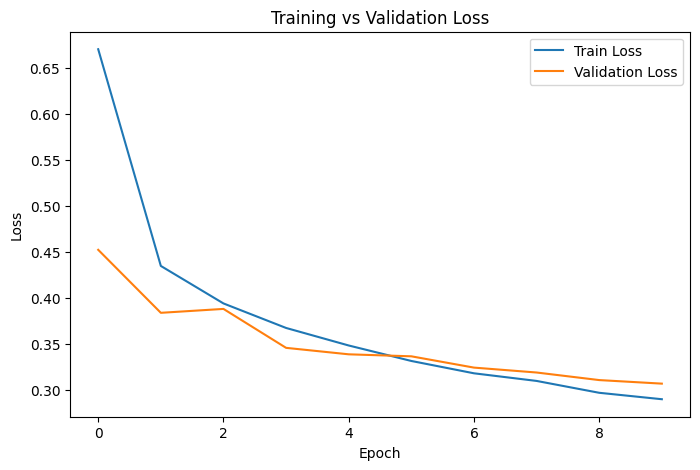

In [ ]:
# 11. Plot Loss Curves

plt.figure(figsize=(8,5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.savefig("accuracy_curve.png")
plt.show()

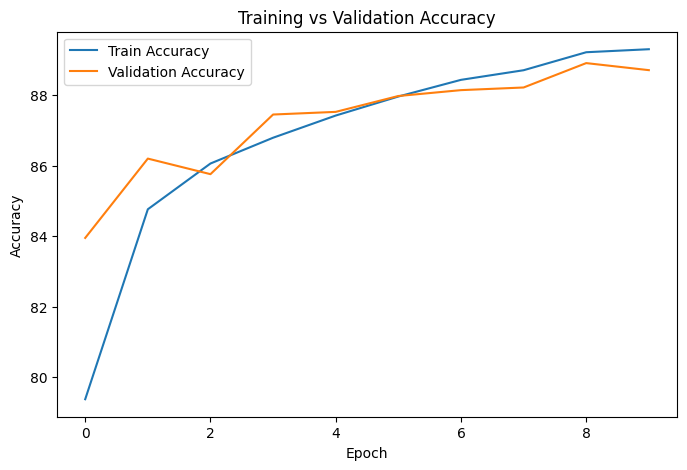

In [ ]:
# 12. Plot Accuracy Curves

plt.figure(figsize=(8,5))
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.savefig("accuracy_curve.png")
plt.show()

In [ ]:
# 14. Classification Report

print(classification_report(y_true, y_pred, target_names=classes))

              precision    recall  f1-score   support

 T-shirt/top       0.83      0.84      0.84      1000
     Trouser       0.99      0.97      0.98      1000
    Pullover       0.78      0.83      0.81      1000
       Dress       0.86      0.91      0.88      1000
        Coat       0.82      0.78      0.80      1000
      Sandal       0.97      0.94      0.95      1000
       Shirt       0.73      0.67      0.70      1000
     Sneaker       0.93      0.95      0.94      1000
         Bag       0.97      0.97      0.97      1000
  Ankle boot       0.95      0.96      0.96      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



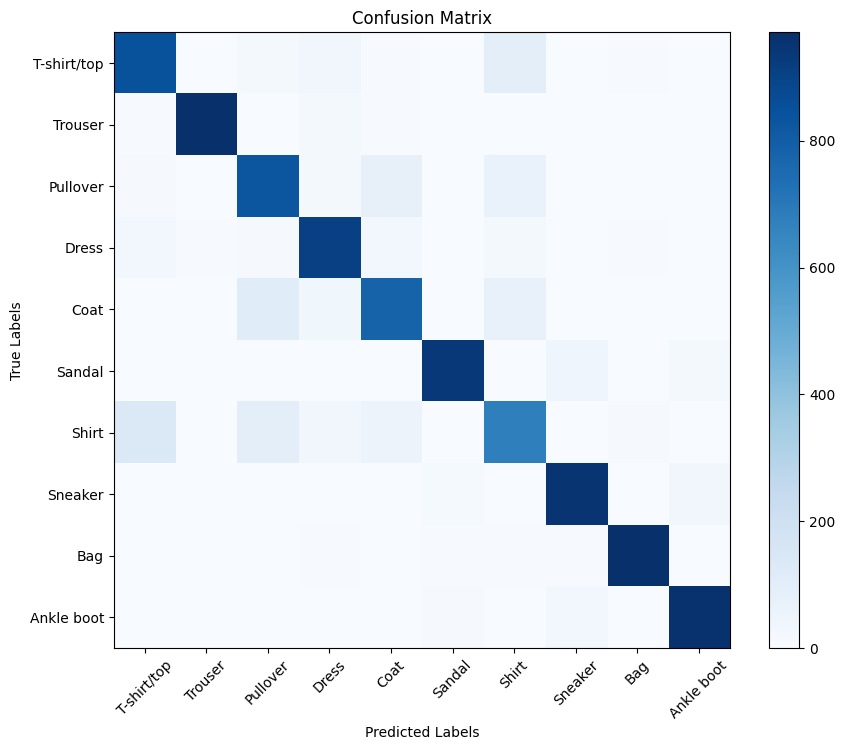

In [ ]:
# 15. Confusion Matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))
plt.imshow(cm, cmap='Blues')

plt.title('Confusion Matrix')
plt.colorbar()

plt.xticks(np.arange(10), classes, rotation=45)
plt.yticks(np.arange(10), classes)

plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.savefig("accuracy_curve.png")
plt.show()